                Лабараториска вежба 1
        Класификација со Naïve Bayes и Gaussian
        Discriminant Analysis модели (LDA и QDA)

In [3]:
#Here I will implement all the libraries I need, so I can solve my exercise
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.preprocessing import LabelEncoder,MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis, LinearDiscriminantAnalysis

# Importing the dataset that I will use
## Description:
An individual’s annual income results from various factors. Intuitively, it is influenced by the individual’s education level, age, gender, occupation, and etc.
## GOAL: predicting income class (over or under 50k)

In [4]:
df = pd.read_csv("adult.csv")

In [5]:
df.head(10)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
5,34,Private,198693,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
6,29,?,227026,HS-grad,9,Never-married,?,Unmarried,Black,Male,0,0,40,United-States,<=50K
7,63,Self-emp-not-inc,104626,Prof-school,15,Married-civ-spouse,Prof-specialty,Husband,White,Male,3103,0,32,United-States,>50K
8,24,Private,369667,Some-college,10,Never-married,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
9,55,Private,104996,7th-8th,4,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,10,United-States,<=50K


# Exploring the dataset
As we see, we have 20 features and total of 41188 data rows, and we have binary classification
Our dataset has no missing values, that is an advantage, so we don't need to prepare anything, besides choosing the important features for usage during model creation.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [7]:
df.isnull().sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [8]:
df.describe()


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [9]:
df.value_counts("income")

income
<=50K    37155
>50K     11687
Name: count, dtype: int64

<Axes: >

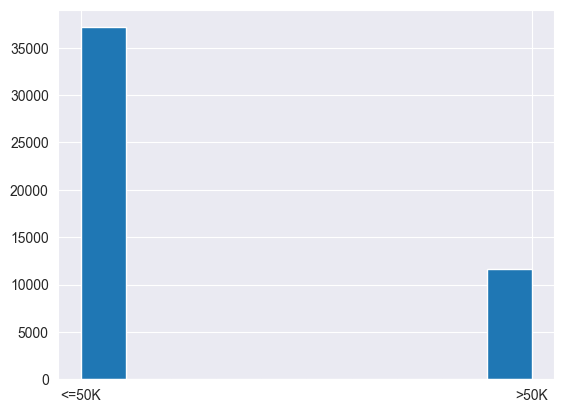

In [10]:
df['income'].hist()

We can see that our dataset is pretty much unbalanced, because the ration of classes is pretty much 1:3 (under50k:over50k)

In [11]:
#Handling all categorical features
encoder = LabelEncoder()
categorical_features = ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race','native-country','gender']
for col in categorical_features:
    df[col] = encoder.fit_transform(df[col])
df['income'] = df['income'].apply(lambda x: 50 if x == '>50K' else -50)

In [12]:
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,4,226802,1,7,4,7,3,2,1,0,0,40,39,-50
1,38,4,89814,11,9,2,5,0,4,1,0,0,50,39,-50
2,28,2,336951,7,12,2,11,0,4,1,0,0,40,39,50
3,44,4,160323,15,10,2,7,0,2,1,7688,0,40,39,50
4,18,0,103497,15,10,4,0,3,4,0,0,0,30,39,-50


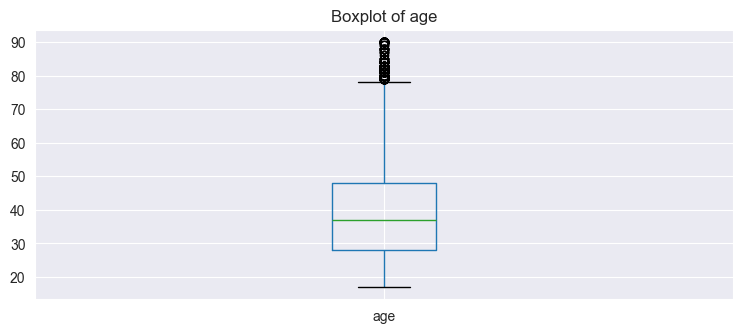

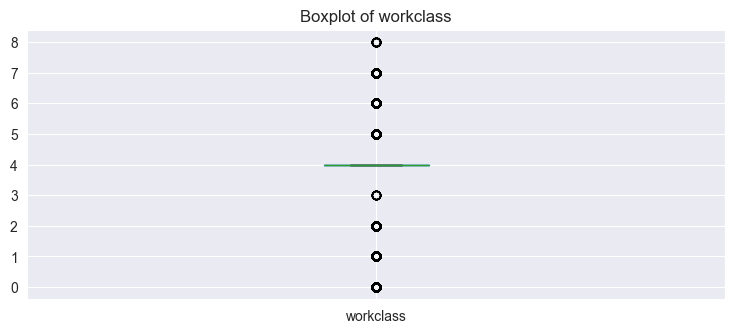

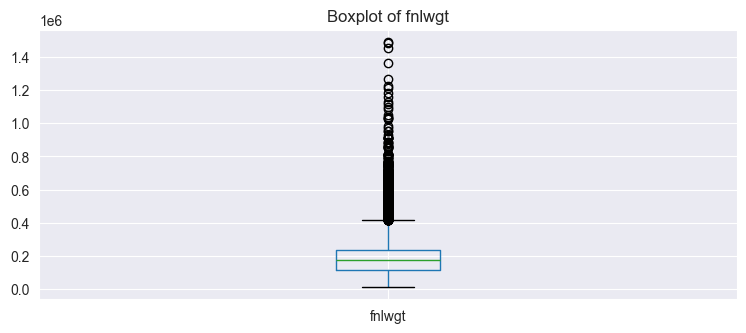

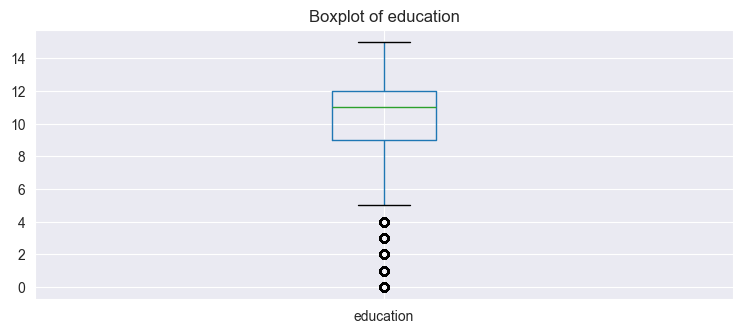

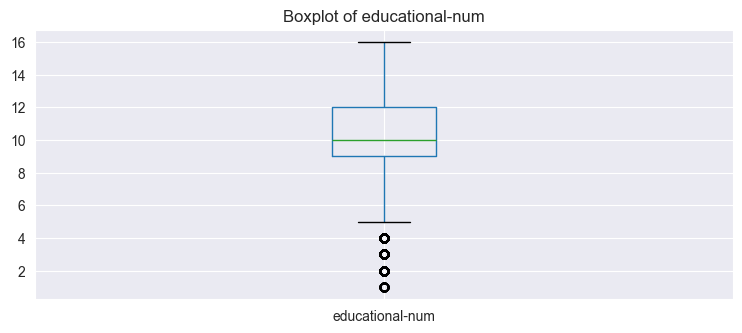

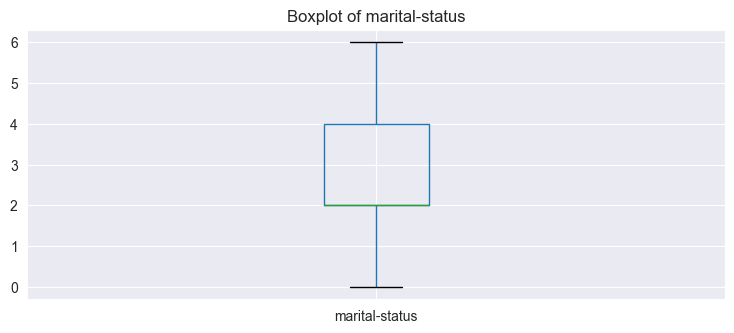

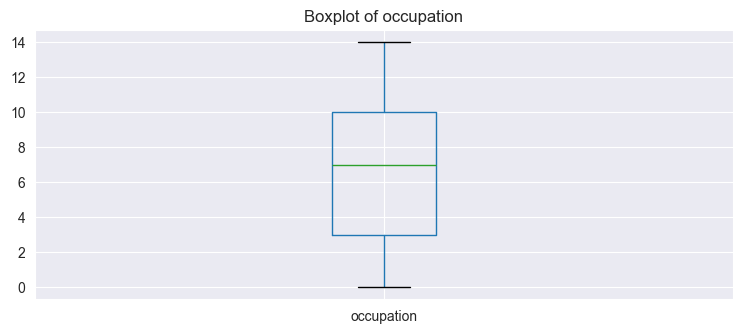

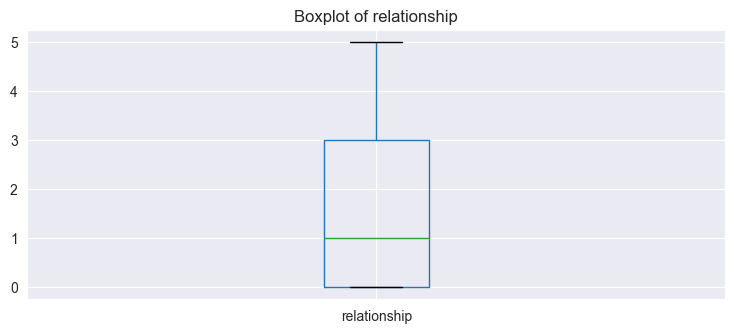

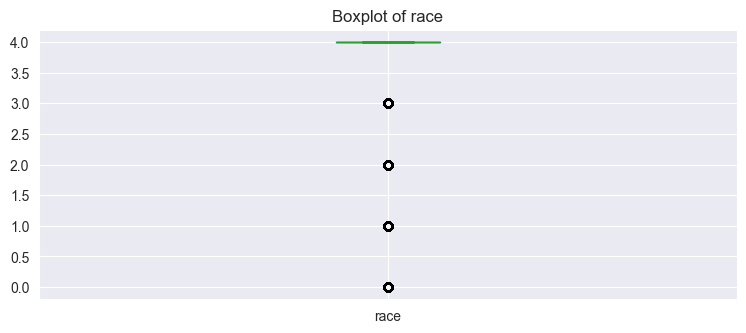

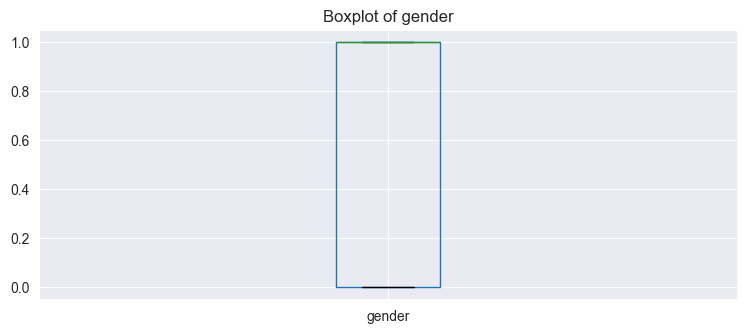

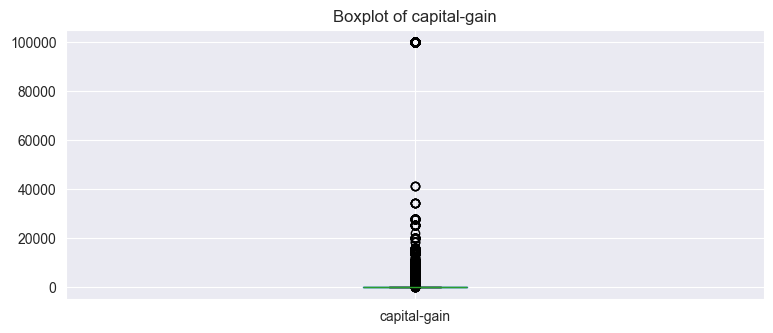

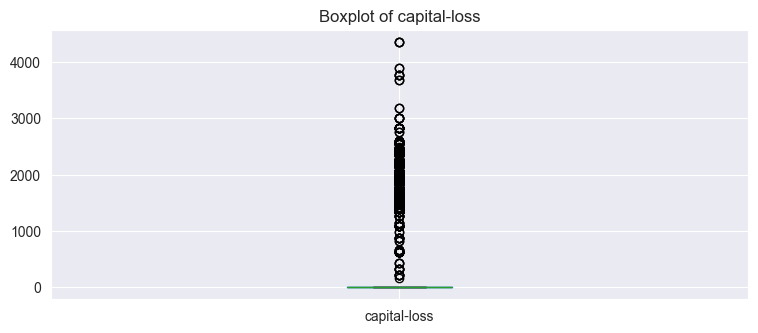

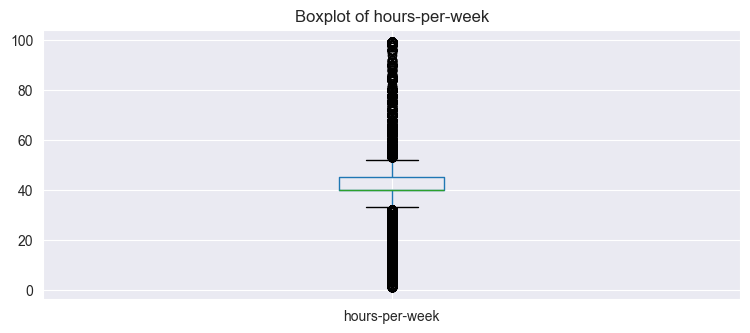

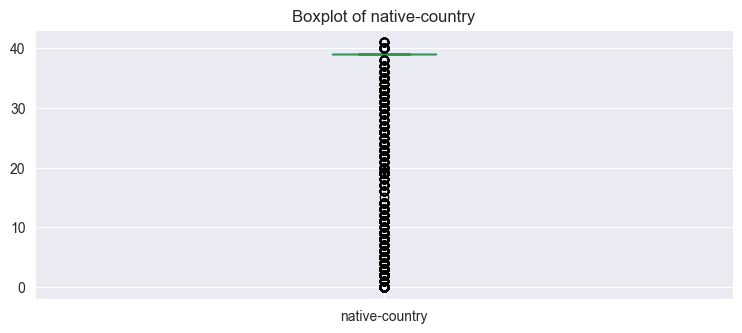

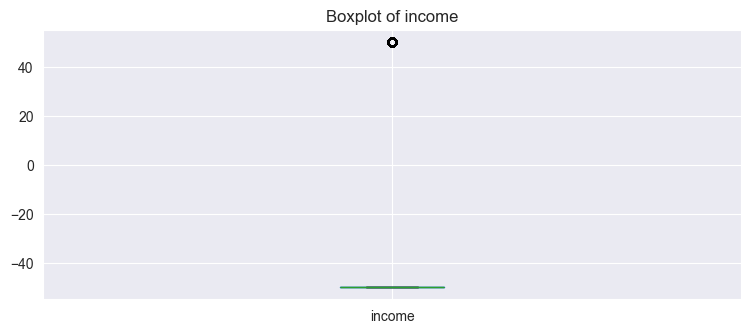

In [13]:
# Generate box plots, including target class
for feature in df.columns:
    plt.figure(figsize=(9, 3.5))
    df.boxplot(column=feature)
    plt.title(f"Boxplot of {feature}")
    plt.show() 

In [14]:
df.value_counts("income")

income
-50    37155
 50    11687
Name: count, dtype: int64

In [15]:
#Now I can see that every of the feature is transformed in numerical value and I can see correlation and mutual information

In [16]:
scaler = MinMaxScaler()
numerical_col = ['fnlwgt','capital-gain','capital-loss','hours-per-week']
df[numerical_col] = scaler.fit_transform(df[numerical_col])

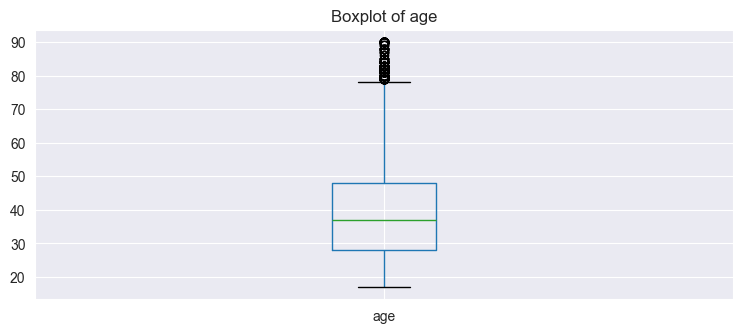

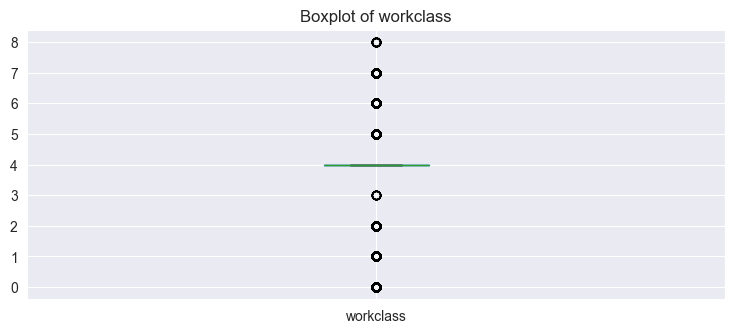

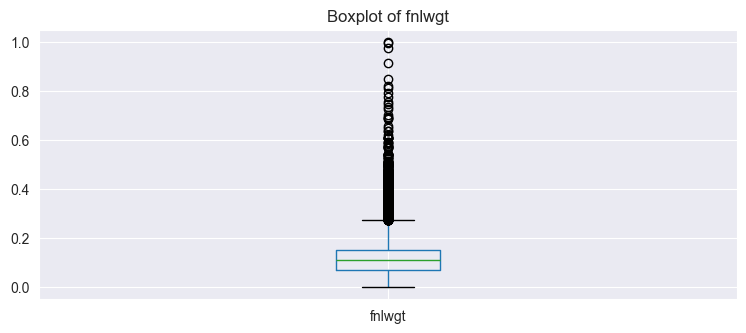

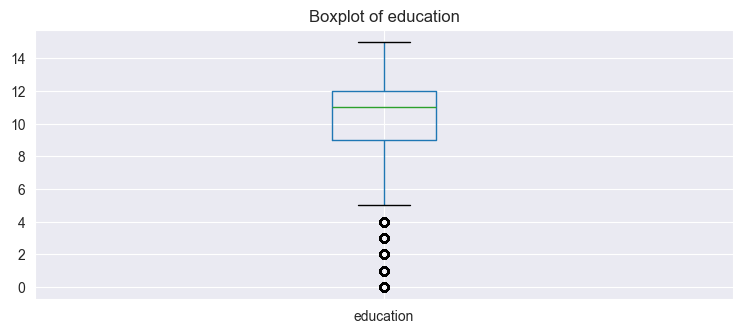

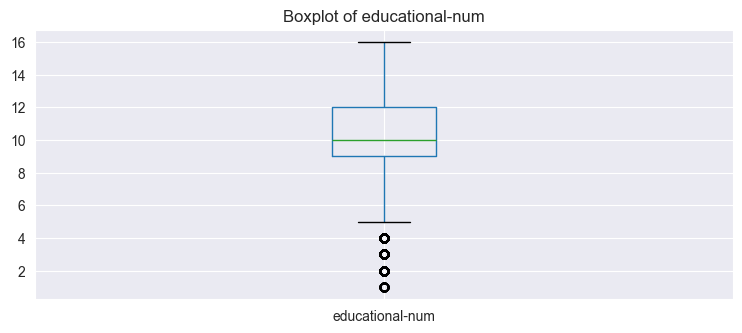

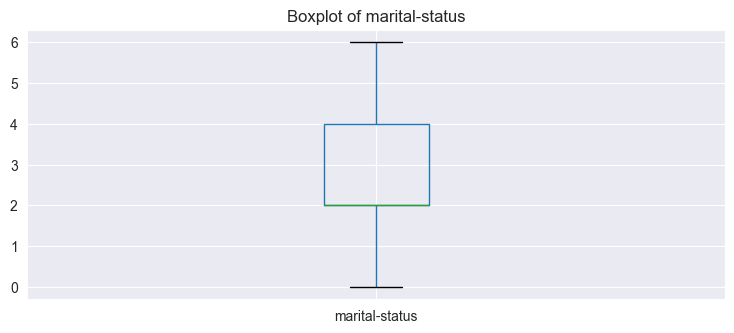

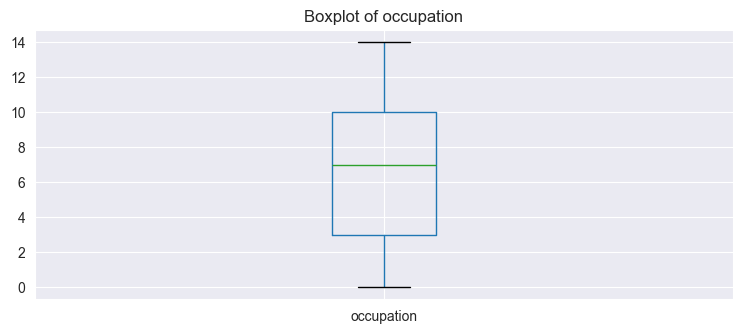

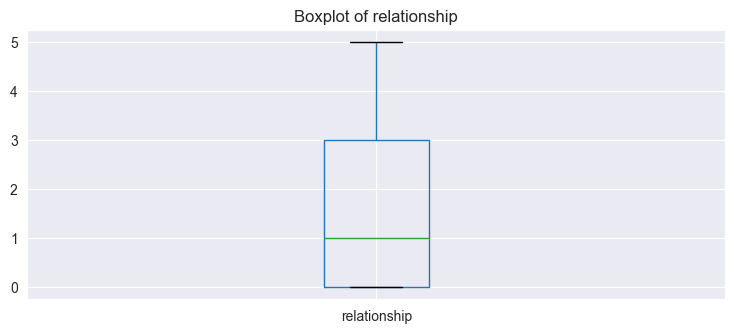

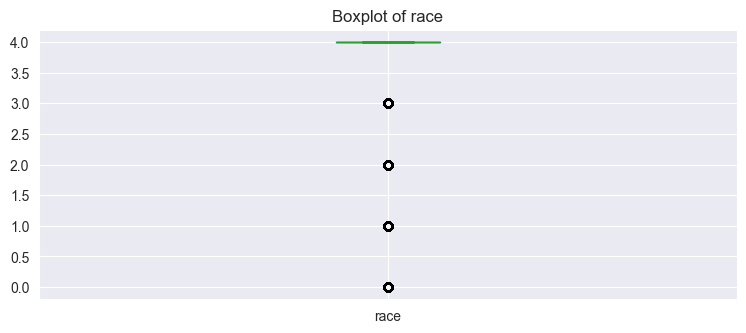

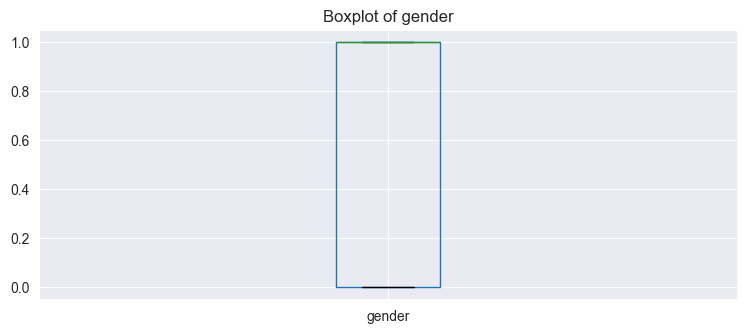

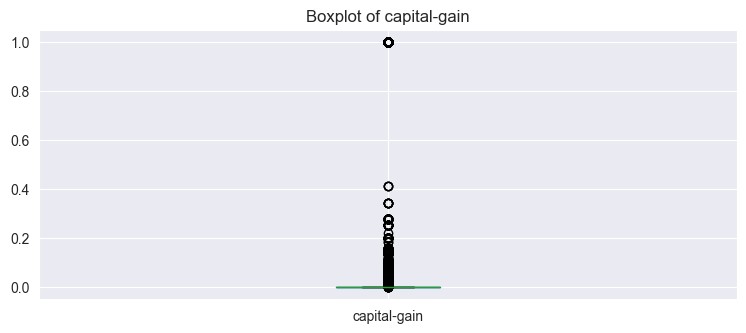

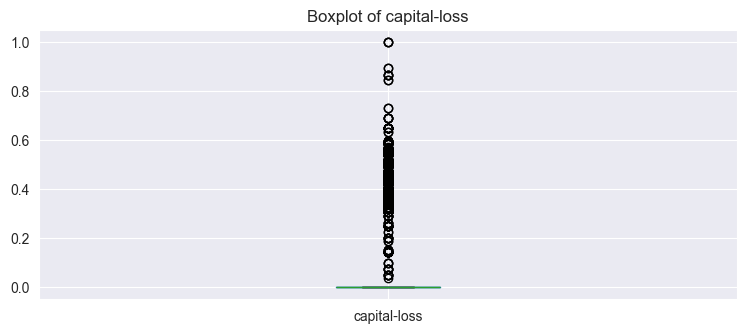

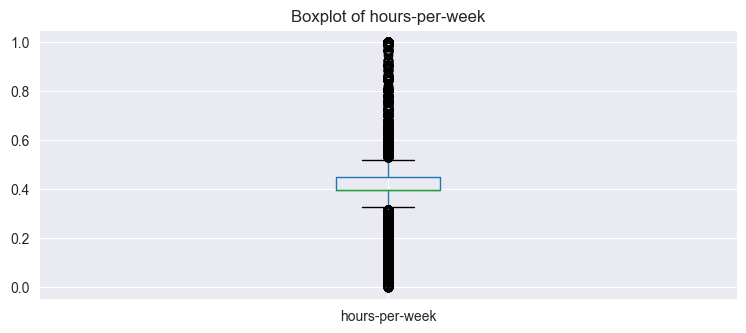

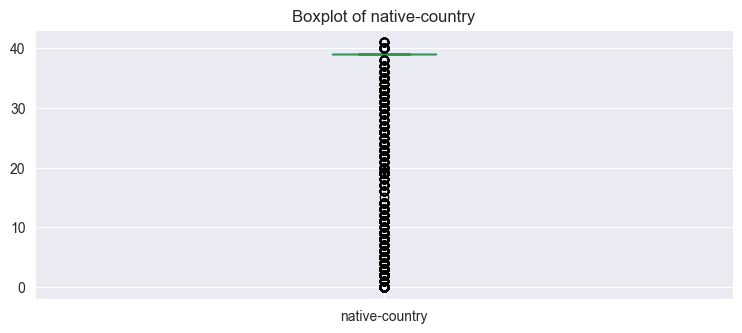

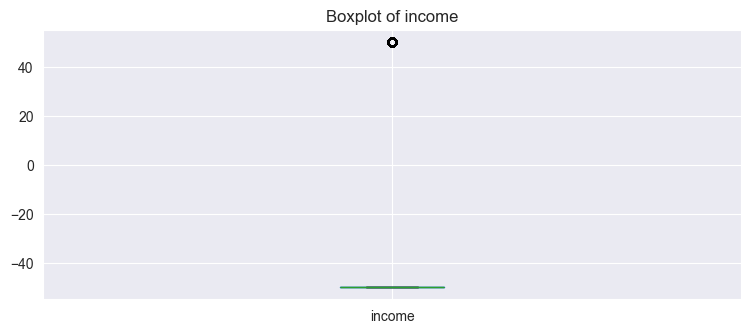

In [17]:
# Generate box plots, including target class
for feature in df.columns:
    plt.figure(figsize=(9, 3.5))
    df.boxplot(column=feature)
    plt.title(f"Boxplot of {feature}")
    plt.show() 

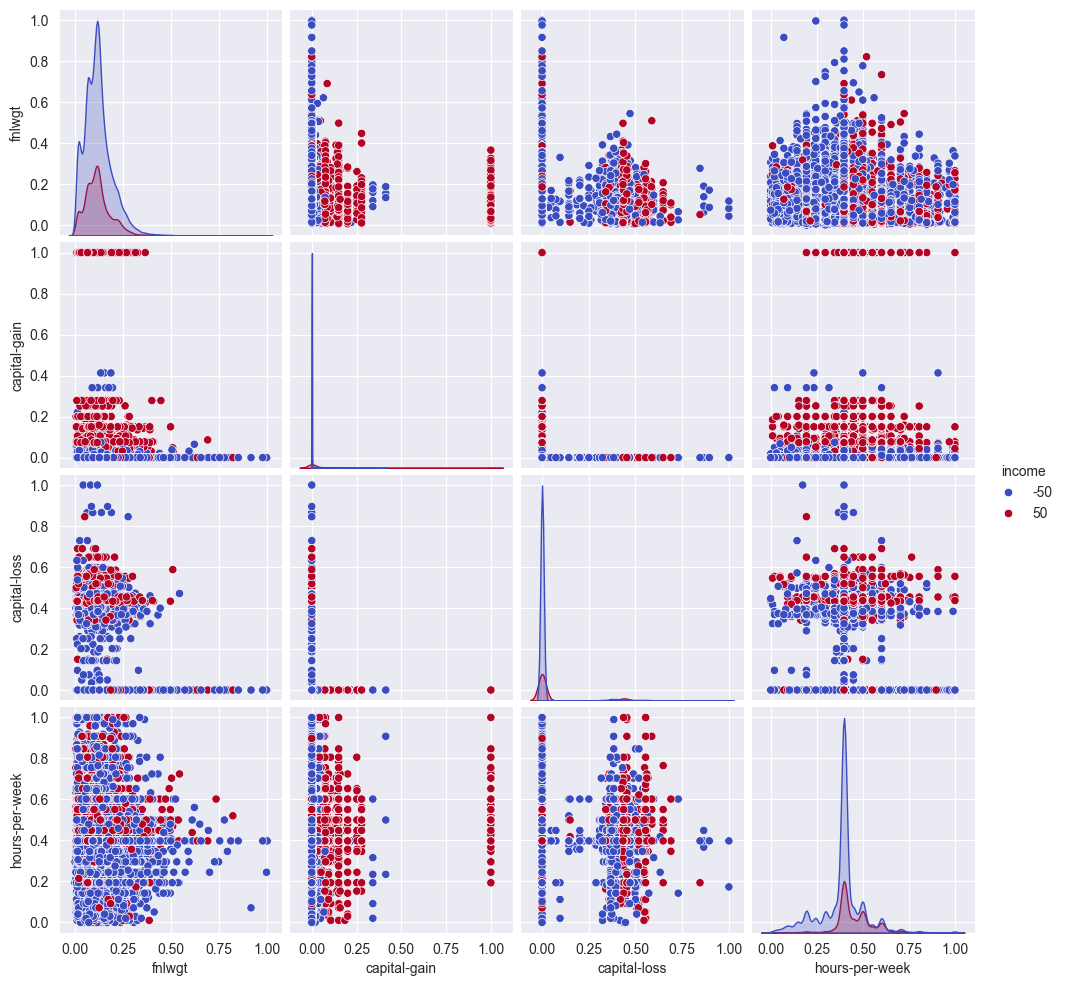

In [18]:
sns.pairplot(df, hue='income',vars=['fnlwgt','capital-gain','capital-loss','hours-per-week'], palette='coolwarm')
plt.show()

As we can see here:
- hours-per-week shows some relation with the income, as higher-work-hours correlate with more income
- no relation with on final weight (fnlwgt)
- capital-loss and gain have some high values, as we can see and they are located very close to 0 (they are not so informative for model creation in ML)

In [19]:
#Mutual Information (only on the numerical feautures)
# Selecting relevant features
features = ['fnlwgt', 'capital-gain', 'capital-loss', 'hours-per-week']
X = df[features]
y = df['income']
# Compute Mutual Information scores
mi_scores = mutual_info_classif(X, y, discrete_features=False, random_state=42)
# visualisation
mi_results = pd.DataFrame({'Feature': features, 'Mutual Information': mi_scores})
mi_results = mi_results.sort_values(by='Mutual Information', ascending=False)

print(mi_results)


          Feature  Mutual Information
1    capital-gain            0.084012
3  hours-per-week            0.040972
0          fnlwgt            0.039503
2    capital-loss            0.036403


## Explanation:
The Mutual Information scores in your output measure how much information each feature provides about the target variable (income).
As we go from top, to bottom, we see that the capital gain has the most information provided for the target variable. Hours-per-hour provide some information, but on the other side fnlwgt does not provide nearly any information (similar to the lowest one).
The lowest is calculated for capital-loss


In [20]:
# #So now, i see that the capital-loss and the fnlwgt does not provide any information and I will drop them
# df = df.drop(columns=['fnlwgt','capital-loss'],axis=1)

In [21]:
df.head(5)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,4,0.145129,1,7,4,7,3,2,1,0.000000,0.0,0.397959,39,-50
1,38,4,0.052451,11,9,2,5,0,4,1,0.000000,0.0,0.500000,39,-50
2,28,2,0.219649,7,12,2,11,0,4,1,0.000000,0.0,0.397959,39,50
3,44,4,0.100153,15,10,2,7,0,2,1,0.076881,0.0,0.397959,39,50
4,18,0,0.061708,15,10,4,0,3,4,0,0.000000,0.0,0.295918,39,-50


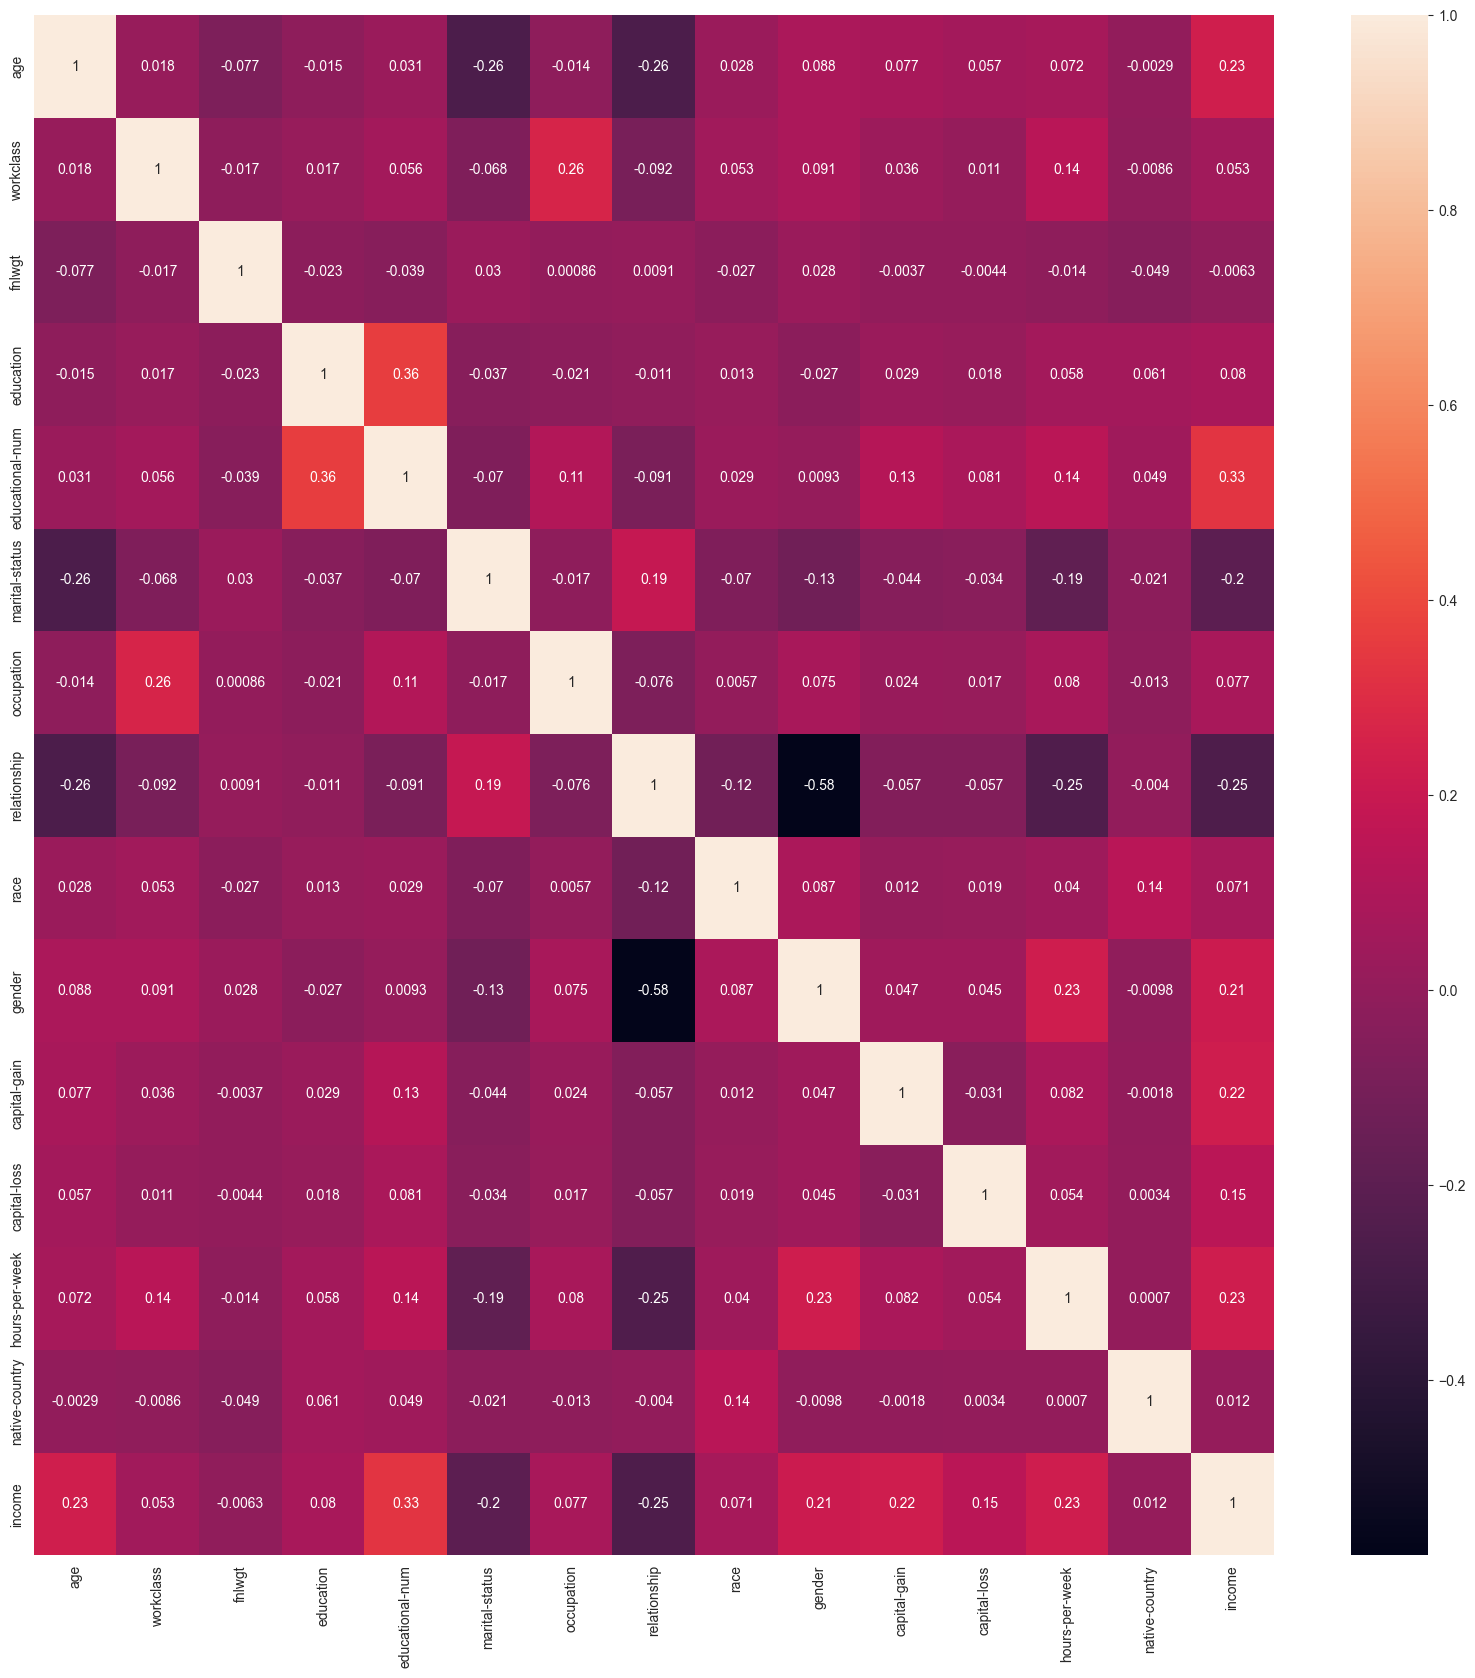

In [22]:
plt.figure(figsize=(20, 20))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [23]:
#From the correlation I don't see any VERY HIGH correlation between these features, so I don't drop anything for now

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
GNB_accuracy = accuracy_score(y_test, y_pred)

print("Accuracy score of the model is ",round(GNB_accuracy,3))

Accuracy score of the model is  0.799


## QDA model


In [26]:
qda = QuadraticDiscriminantAnalysis() 
qda.fit(X_train, y_train)

QuadraticDiscriminantAnalysis()

In [30]:
print(f"Class 1 has {qda.priors_[0]}")
print(f"Class 2 has {qda.priors_[1]}")

Class 1 has 0.7595014460113122
Class 2 has 0.24049855398868783


In [32]:
y_pred = qda.predict(X_test)
qda_acc_score = accuracy_score(y_test, y_pred)
print(f"Accuracy score od the QDA model is {round(qda_acc_score,3)}, or {round(qda_acc_score,3)*100}%")

Accuracy score od the model is 0.799, or 79.9%


## LDA model 

In [33]:
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

In [34]:
print(f"Class 1 has {lda.priors_[0]}")
print(f"Class 2 has {lda.priors_[1]}")

Class 1 has 0.7595014460113122
Class 2 has 0.24049855398868783


In [35]:
y_pred = lda.predict(X_test)
lda_acc_score = accuracy_score(y_test, y_pred)
print(f"Accuracy score od the LDA model is {round(lda_acc_score,3)}, or {round(lda_acc_score,3)*100}%")

Accuracy score od the LDA model is 0.779, or 77.9%


As we can see, we get a slightly better results when using QDA model instead of LDA on the same dataset.
This can be attributed to the fact that QDA estimates a separate covariance matrix for each class, allowing it to model class-specific variance more flexibly. In contrast, LDA assumes a shared covariance matrix across all classes, which can be a limiting assumption if the true class distributions have different covariance structures.

# USING REDUCED DIMENSIONALITY

In [38]:
df.value_counts("income")

income
-50    37155
 50    11687
Name: count, dtype: int64

So as we see, we have only 2 classes. I want to show the lda reduction, I need to follow the rule that says 'Number od components must be less than number of classes'
So I have 2 classes, and I will reduce to 1 component.

In [44]:
X = df.drop(columns=['income'], axis=0)
y = df['income']

In [46]:
X.head(5)

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
0,25,4,0.145129,1,7,4,7,3,2,1,0.000000,0.0,0.397959,39
1,38,4,0.052451,11,9,2,5,0,4,1,0.000000,0.0,0.500000,39
2,28,2,0.219649,7,12,2,11,0,4,1,0.000000,0.0,0.397959,39
3,44,4,0.100153,15,10,2,7,0,2,1,0.076881,0.0,0.397959,39
4,18,0,0.061708,15,10,4,0,3,4,0,0.000000,0.0,0.295918,39


In [47]:
y.head(5)

0   -50
1   -50
2    50
3    50
4   -50
Name: income, dtype: int64

In [54]:
lda_reducing_model = LinearDiscriminantAnalysis(n_components=1)
lda_reducing_model.fit(X, y)
X_reduced = lda_reducing_model.transform(X)

In [55]:
X_reduced_train, X_reduced_test, y_reduced_train, y_reduced_test = train_test_split(X_reduced, y, test_size=0.2, random_state=42)

In [63]:
QDA_reduced = QuadraticDiscriminantAnalysis()
QDA_reduced.fit(X_reduced_train, y_reduced_train)
y_pred = QDA_reduced.predict(X_reduced_test)
qda_reduced_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of QDA with reduced is {round(qda_reduced_accuracy,3)}, or {round(qda_reduced_accuracy,3)*100}%")

Accuracy of QDA with reduced is 0.818, or 81.8%


In [64]:
lda_reduced = LinearDiscriminantAnalysis()
lda_reduced.fit(X_reduced_train, y_reduced_train)
y_pred = lda_reduced.predict(X_reduced_test)
lda_reduced_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of LDA with reduced is {round(lda_reduced_accuracy,3)}, or {round(lda_reduced_accuracy,3)*100}%")

Accuracy of LDA with reduced is 0.82, or 82.0%


In [66]:
gnb_reduced = GaussianNB()
gnb_reduced.fit(X_reduced_train, y_reduced_train) 
y_pred = gnb_reduced.predict(X_reduced_test)
gnb_reduced_accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of Gaussian Naive Bayes with reduced is {round(gnb_reduced_accuracy,3)}, or {round(gnb_reduced_accuracy,3)*100}%")

Accuracy of Gaussian Naive Bayes with reduced is 0.818, or 81.8%
